# Week 09 — Home exercise 3: Fifty-five years, finished properly

**Solution proposal.**

Taking one line chart from unreadable to publishable, and then drawing the same data a second way to
show that the chart type is a choice.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

nasdaq = pd.read_csv("../data/NASDAQ.csv")
nasdaq["Date"] = pd.to_datetime(nasdaq["Date"], format="%Y-%m-%d")

prices = nasdaq.set_index("Date").sort_index()["NASDAQ"]

print(len(prices), "trading days,", prices.index.min().date(), "to", prices.index.max().date())

13842 trading days, 1971-02-05 to 2025-12-30


## 1. Monthly, from 1990, as it comes

432 months


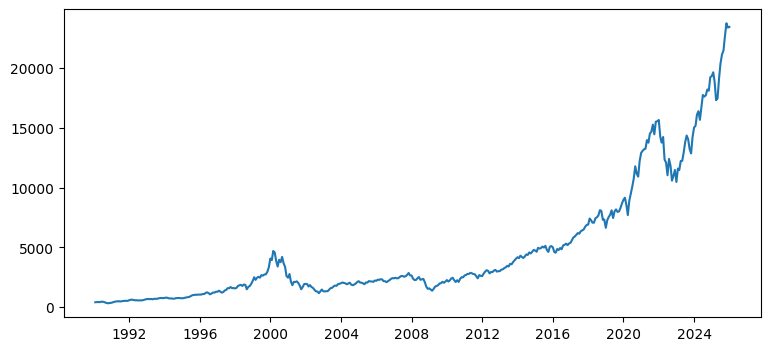

In [2]:
monthly = prices.resample("ME").last().loc["1990":]

print(len(monthly), "months")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly.values)

# Unreadable: the index runs from 459 to 23 419, so a linear axis gives the
# whole of the 1990s about two percent of the height of the figure.

The dates on the x-axis are right without being asked, because the index is a real datetime — that is
what `to_datetime` bought.

The y-axis is the problem. The index starts this slice at 459 and ends above 23 000, so on a linear
scale the entire 1990s, including a bull market that quadrupled the index, is a flat line along the
bottom. The only thing the chart shows is that the number got big recently.

## 2. A scale where a percentage is a percentage

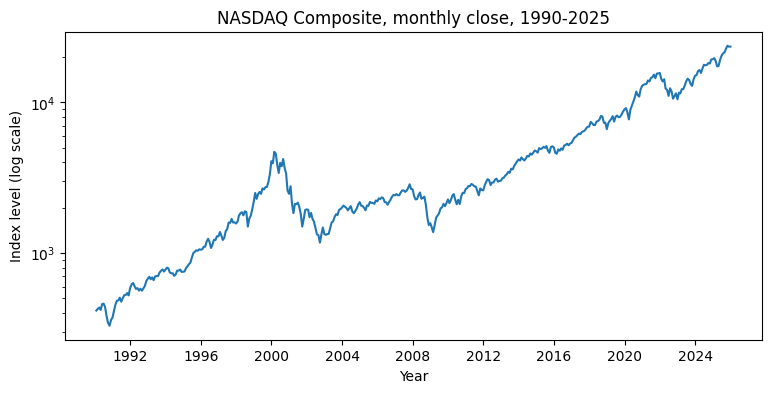

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly.values)

ax.set_yscale("log")
ax.set_xlabel("Year")
ax.set_ylabel("Index level (log scale)")
ax.set_title("NASDAQ Composite, monthly close, 1990-2025");

On a logarithmic axis, equal vertical distances are equal **ratios**. A halving looks the same size in
1995 as in 2020, which is what you want from a chart of anything that grows by compounding.

Saying `(log scale)` in the axis label is not optional. A reader who assumes a linear axis will
misread every distance on the figure.

## 3. Finding the four dates

In [4]:
dotcom_peak = prices.loc["2000"].idxmax()
dotcom_low = prices.loc["2002"].idxmin()

gfc_peak = prices.loc["2007"].idxmax()
gfc_low = prices.loc["2008":"2009"].idxmin()

for label, start, end in [("dot-com   ", dotcom_peak, dotcom_low),
                          ("financial ", gfc_peak, gfc_low)]:
    fall = (prices[end] / prices[start] - 1) * 100
    print(f"{label} {start.date()} {prices[start]:8.1f}  ->  {end.date()} {prices[end]:8.1f}   {fall:6.1f}%")

dot-com    2000-03-10   5048.6  ->  2002-10-09   1114.1    -77.9%
financial  2007-10-31   2859.1  ->  2009-03-09   1268.6    -55.6%


Found rather than typed, which matters: had the file been extended or corrected, these four dates would
follow it instead of quietly becoming wrong.

`idxmax` and `idxmin` return the **index label** at the extreme value, and because the index is a
datetime, that label is a date. Slicing the series by year first — `prices.loc["2007"]` — is what
confines the search to the period you mean.

## 4 and 5. The finished figure

saved


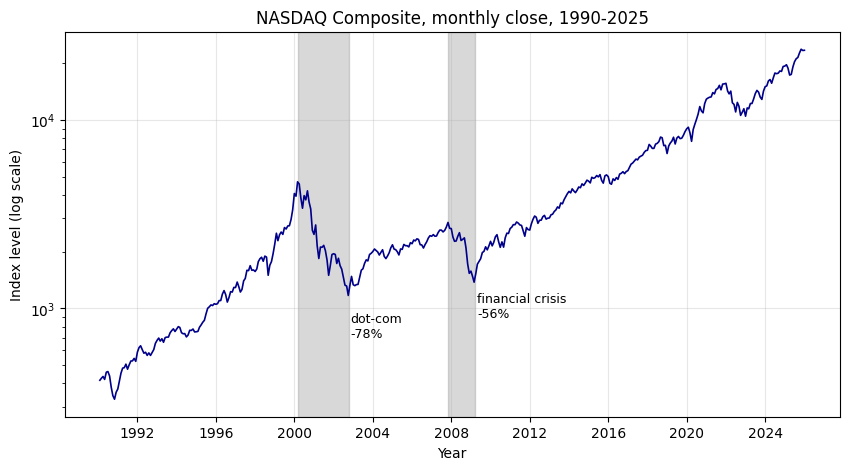

In [5]:
dotcom_fall = (prices[dotcom_low] / prices[dotcom_peak] - 1) * 100
gfc_fall = (prices[gfc_low] / prices[gfc_peak] - 1) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly.index, monthly.values, linewidth=1.2, color="darkblue")

ax.axvspan(dotcom_peak, dotcom_low, color="gray", alpha=0.3)
ax.axvspan(gfc_peak, gfc_low, color="gray", alpha=0.3)

ax.text(pd.Timestamp("2002-11-01"), 700, f"dot-com\n{dotcom_fall:.0f}%", fontsize=9)
ax.text(pd.Timestamp("2009-05-01"), 900, f"financial crisis\n{gfc_fall:.0f}%", fontsize=9)

ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_xlabel("Year")
ax.set_ylabel("Index level (log scale)")
ax.set_title("NASDAQ Composite, monthly close, 1990-2025")

fig.savefig("nasdaq-history.png", dpi=300, bbox_inches="tight")
print("saved")

The figure now makes two specific claims, each attached to the part of the line it is about, and a
reader can check both against the shading.

`dpi=300` because 300 is the convention for print; `bbox_inches="tight"` because without it the y-axis
label is close enough to the edge to be at risk. The file lands in this folder, and it is a **derived**
file — the notebook made it, so it does not belong in git.

## 6. The same data as annual returns

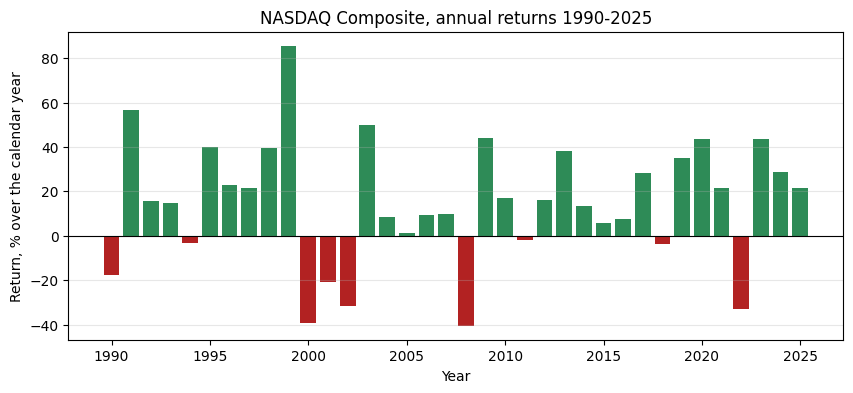

In [6]:
annual = prices.resample("YE").last()
returns = (annual.pct_change() * 100).loc["1990":]

colors = ["firebrick" if value < 0 else "seagreen" for value in returns]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(returns.index.year, returns.values, color=colors)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Return, % over the calendar year")
ax.set_title("NASDAQ Composite, annual returns 1990-2025")
ax.grid(True, axis="y", alpha=0.3);

In [7]:
print("negative years:", (returns < 0).sum(), "of", returns.notna().sum())
print("best: ", returns.idxmax().year, round(returns.max(), 1), "%")
print("worst:", returns.idxmin().year, round(returns.min(), 1), "%")

negative years: 9 of 36
best:  1999 85.6 %
worst: 2008 -40.5 %


`returns.index.year` rather than `returns.index`: the index is a datetime at the end of each December,
and a bar chart wants a category per bar, not a position on a time axis. Nine losing years out of 36.

The list comprehension building `colors` is the same pattern as the labels in the lecture — one entry
per bar, in the same order as the bars, handed to `ax.bar` as its `color` argument.

### Which figure goes in the report?

**Both, and they are not substitutes.**

- The **line chart** answers *"what has this index done?"* It is the right figure for anything about
  the long run, about the scale of the two crashes, or about how long recovery took.
- The **bar chart** answers *"what is a year in this market like?"* It is the right figure for anything
  about risk. Nine losing years out of 36, one of them -40%, is invisible in the line chart, where 2008
  is a downward kink and the eye slides over it.

If forced to one: the bar chart, and only because most people already assume the line chart's story and
are surprised by the bar chart's.

### Things worth noticing

- **`resample("ME").last()` before plotting.** 13 842 daily points on a 10-inch figure is roughly 1 400
  points per inch, so the line is a solid smear and the file is enormous. Downsampling to 432 monthly
  points changes nothing visible and makes the figure honest about its own resolution.
- **`ax.axvspan` takes the same kind of value as the x-axis.** Because the axis is dates, the shading
  bounds are `Timestamp` objects, which is exactly what `idxmax` returned — no conversion needed.
- **The two-line annotation** uses `\n` inside an f-string. Any string matplotlib draws can contain
  newlines.

### What this notebook does NOT do

- **The two crash periods are peak-to-trough, chosen after the fact.** Picking the highest and lowest
  point of a period always produces a dramatic number, and no investor bought at exactly the top. The
  figure would be more honest with the shading running from the peak to the recovery than from the peak
  to the trough.
- **These are index returns, not investor returns** — no dividends, no fees, no tax, and the
  composition of the index changed completely over the period.
- **Nothing here adjusts for inflation.** A 3% nominal return in 1990 and in 2020 are not the same
  thing, and the log axis, which is careful about ratios, is silent about that.
- **It never checks the file for gaps.** After `resample("ME").last()`, a month with three trading days
  in it produces a number that looks exactly like every other month.